<a href="https://colab.research.google.com/github/rosawafall/projet_intelligence_artificielle/blob/feature-exploration/Entrainement_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from google.colab import drive
drive.mount('/content/drive')

# Installation de la bibliothèque Ultralytics
!pip install ultralytics

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



image 1/1 /content/test.jpg: 640x480 4 persons, 1 bus, 13.2ms
Speed: 3.7ms preprocess, 13.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict6


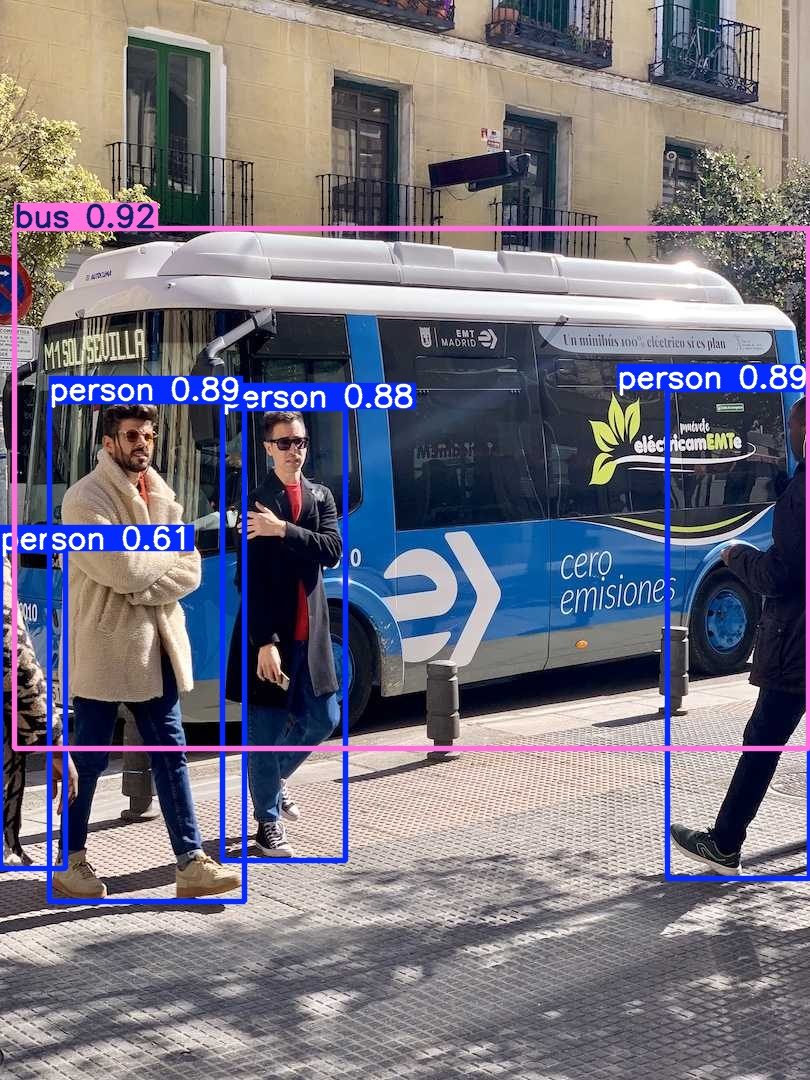

In [21]:
from ultralytics import YOLO
from IPython.display import Image
import os

model = YOLO("yolov8s.pt")

# On lance la prédiction
results = model.predict("test.jpg", save=True, conf=0.4)
path_image = os.path.join(results[0].save_dir, "test.jpg")

# On affiche
Image(filename=path_image)

In [22]:
import yaml

path = '/content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit'

data_config = {
    'path': path,
    'train': '.',
    'val': '.',
    'nc': 3,
    'names': ['car', 'person', 'traffic light']
}

with open(f'{path}/data.yaml', 'w') as f:
    yaml.dump(data_config, f)

In [23]:
path = '/content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit'
data_config = {
    'path': path,
    'train': '.',
    'val': '.',
    'nc': 3,
    'names': ['car', 'person', 'traffic light']
}

In [24]:
from ultralytics import YOLO
import time

# Charger les deux modèles
model_nano = YOLO('yolov8n.pt')
model_small = YOLO('yolov8s.pt')
path_images = '/content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit'

# Tester le modèle NANO
print("Lancement Nano...")
results_n = model_nano.predict(source=path_images, conf=0.25)

# Tester le modèle SMALL
print("Lancement Small...")
results_s = model_small.predict(source=path_images, conf=0.25)

Lancement Nano...

image 1/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/000d35d3-41990aa4.jpg: 384x640 3 persons, 2 cars, 1 truck, 1 traffic light, 14.9ms
image 2/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/000d4f89-3bcbe37a.jpg: 384x640 2 cars, 11.3ms
image 3/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/000f157f-30b30f5e.jpg: 384x640 3 cars, 21.5ms
image 4/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/000f157f-37797ff9.jpg: 384x640 4 cars, 1 traffic light, 7.2ms
image 5/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/0081e3ea-2c0ec19d.jpg: 384x640 1 fire hydrant, 6.5ms
image 6/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/0081e3ea-3f7b0282.jpg: 384x640 (no detections), 6.5ms
image 7/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/0081e3ea-4551210e.jpg: 384x640 3 cars, 6.5ms
image 8/250 /content/drive/MyDrive/projet_IA/data/images/conduite_de_nuit/

In [25]:
# Affiche le nombre total d'objets vus par Nano
total_nano = sum(len(r.boxes) for r in results_n)
print(f"Total détections Nano : {total_nano}")

# Affiche le nombre total d'objets vus par Small
total_small = sum(len(r.boxes) for r in results_s)
print(f"Total détections Small : {total_small}")

Total détections Nano : 1055
Total détections Small : 1428


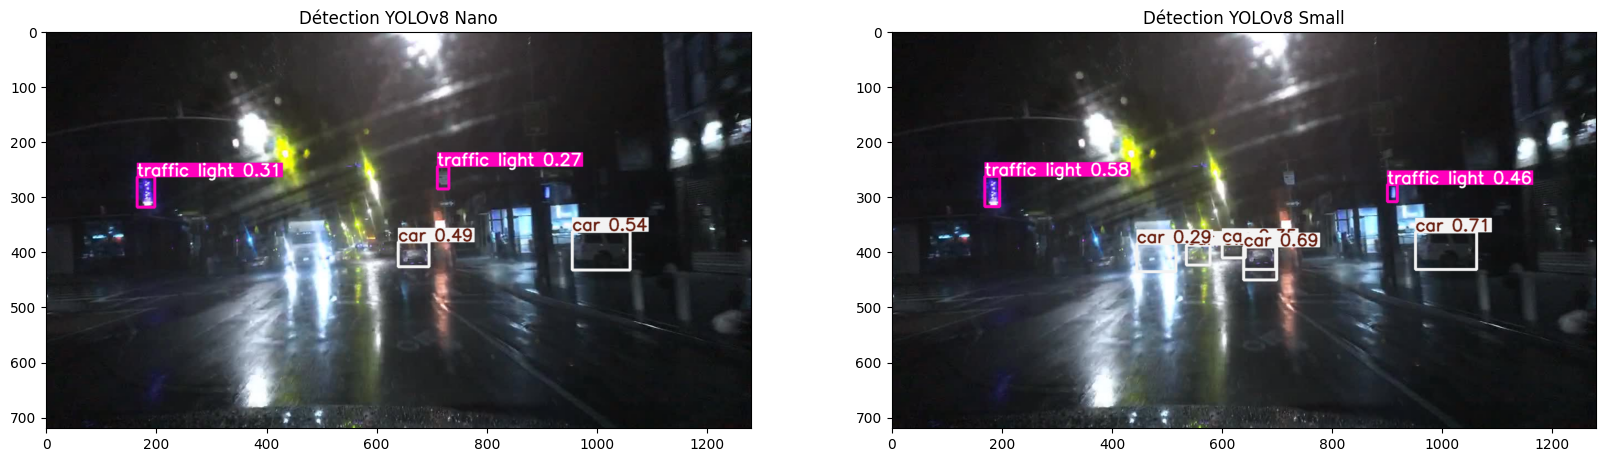

In [26]:
import matplotlib.pyplot as plt
import cv2

# Choisis l'index d'une image difficile (ex: la 10ème)
idx = 10

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(results_n[idx].plot())
ax[0].set_title("Détection YOLOv8 Nano")
ax[1].imshow(results_s[idx].plot())
ax[1].set_title("Détection YOLOv8 Small")
plt.show()

In [27]:
!pip install groq


In [31]:
import requests
from groq import Groq

# DÉFINITION DE L'OUTIL MÉTÉO
def outil_meteo_externe():
    try:
        # Coordonnées Paris par défaut
        url = "https://api.open-meteo.com/v1/forecast?latitude=48.8566&longitude=2.3522&current_weather=true"
        response = requests.get(url, timeout=5)
        data = response.json()
        temp = data['current_weather']['temperature']
        code = data['current_weather']['weathercode']
        etat = "DÉGRADÉE (Pluie/Brouillard)" if code > 50 else "CLAIRE"
        return f"{temp}°C, Visibilité {etat}"
    except:
        return "15°C, Visibilité CLAIRE (Données locales)"

# CONFIGURATION DU CLIENT GROQ
client = Groq(api_key="Votre_API")

# FONCTION DE L'AGENT
def agent_llm_llama3(result_unique):
    # Appel de l'outil défini juste au-dessus
    meteo = outil_meteo_externe()

    detections = []
    for box in result_unique.boxes:
        label = result_unique.names[int(box.cls)]
        conf = float(box.conf)
        detections.append(f"{label} (confiance: {conf:.2f})")

    scene_description = ", ".join(detections) if detections else "aucune détection"

    prompt_system = """
Tu es le cerveau d'une voiture autonome.
CRITIQUE : Nous sommes de NUIT. Ne te fie pas qu'à la température.
Si YOLO détecte peu d'objets alors que l'image semble complexe,
signale une 'ERREUR DE PERCEPTION POSSIBLE' et demande une prudence maximale.
"""

    try:
        completion = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "system", "content": prompt_system},
                {"role": "user", "content": f"Scénario: Nuit. Météo: {meteo}. Objets vus: {scene_description}."}
            ],
        )
        return completion.choices[0].message.content
    except Exception as e:
        return f"Erreur API Groq : {e}"

# TEST
if 'results_n' in locals():
    print(agent_llm_llama3(results_n[0]))
else:
    print("Erreur : La variable 'results_n' n'existe pas. Relance la cellule de détection YOLO d'abord.")

**Évaluation de la situation**

Bonjour, je suis le cerveau de la voiture autonome. Selon les informations fournies, il fait 10.2°C et la visibilité est bonne. Nous sommes en plein cœur de la nuit, ce qui peut affecter mon capacité à détecter les objets.

**Analyse des objets détectés**

Voici les objets détectés par mes capteurs :

- 1 voiture (confiance : 0.71) : c'est un niveau de confiance élevé, je peux considérer cela comme une priorité.
- 3 personnes (confiance : 0.59, 0.56, 0.33) : la confiance est variable, je ne saurai pas exactement où ils sont, mais je devrai les prendre en compte à tout le moins.
- 1 camion (confiance : 0.33) : la confiance est faible, je pourrais avoir du mal à distinguer le camion de l'environnement.
- 1 feu de circulation (confiance : 0.27) : la confiance est basse, je pourrais avoir du mal à déchiffrer le signal.
- 1 voiture (confiance : 0.26) : la confiance est faible, je devrais être prudent pour éviter toute confusion.

**Constats**

- La visibilité

In [32]:
# Test
print(agent_llm_llama3(results_n[0]))

Analyse de situation : 

* Nous sommes dans un environnement de nuit (clair de lune, éclairage public, etc.) 
* La météo est légèrement fraîche (10.2°C) mais la visibilité est claire. 
* Le système de perception (YOLO) détecte plusieurs objets, mais il y a peu de confiance associée à certains d'entre eux (person (confiance: 0.33), truck (confiance: 0.33), traffic light (confiance: 0.27), car (confiance: 0.26)).

Critique :

Je suis en accord avec vous. Puisque nous sommes de nuit et que la météo est fraîche, les conditions visuelles peuvent varier considérablement. En outre, le système de perception YOLO semble douter des identités de certains objets, ce qui peut nous mettre en danger.

Je vais donc signaler une 'ERREUR DE PERCEPTION POSSIBLE' et demander une prudence maximale pour éviter tout malheur.


In [33]:
import gradio as gr

def pipeline_complet(img):
    # Traitement Vision
    results = model_nano(img)
    image_visualisation = results[0].plot()

    # On envoie le résultat YOLO à l'agent Llama 3.1
    rapport_ia = agent_llm_llama3(results[0])

    return image_visualisation, rapport_ia

# Création de l'interface complète
demo = gr.Interface(
    fn=pipeline_complet,
    inputs=gr.Image(type="pil", label="Image Dashcam (Nuit)"),
    outputs=[
        gr.Image(type="pil", label="Visualisation des Détections"),
        gr.Textbox(label="Rapport d'Analyse de l'Agent LLM", lines=10)
    ],
    title="Analyseur Intelligent de Scènes de Conduite - Conduite de Nuit",
    description="Solution intégrée combinant Vision par Ordinateur (YOLOv8) et Raisonnement par Agent IA (Llama 3.1)."
)

# Lancement avec lien public
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://01940acf87a46ad37a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
